#### Dataset from: https://www.kaggle.com/competitions/titanic

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

In [26]:
df = pd.read_csv('titanic.csv')
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

/tmp/ipykernel_27905/4057910391.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


## Basic EDA

In [27]:
# HEAD
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [28]:
# SHAPE
print("Shape:", df.shape)

Shape: (891, 12)


In [29]:
# TIPE DATA
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [30]:
# STATISTIK DESKRIPTIF
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


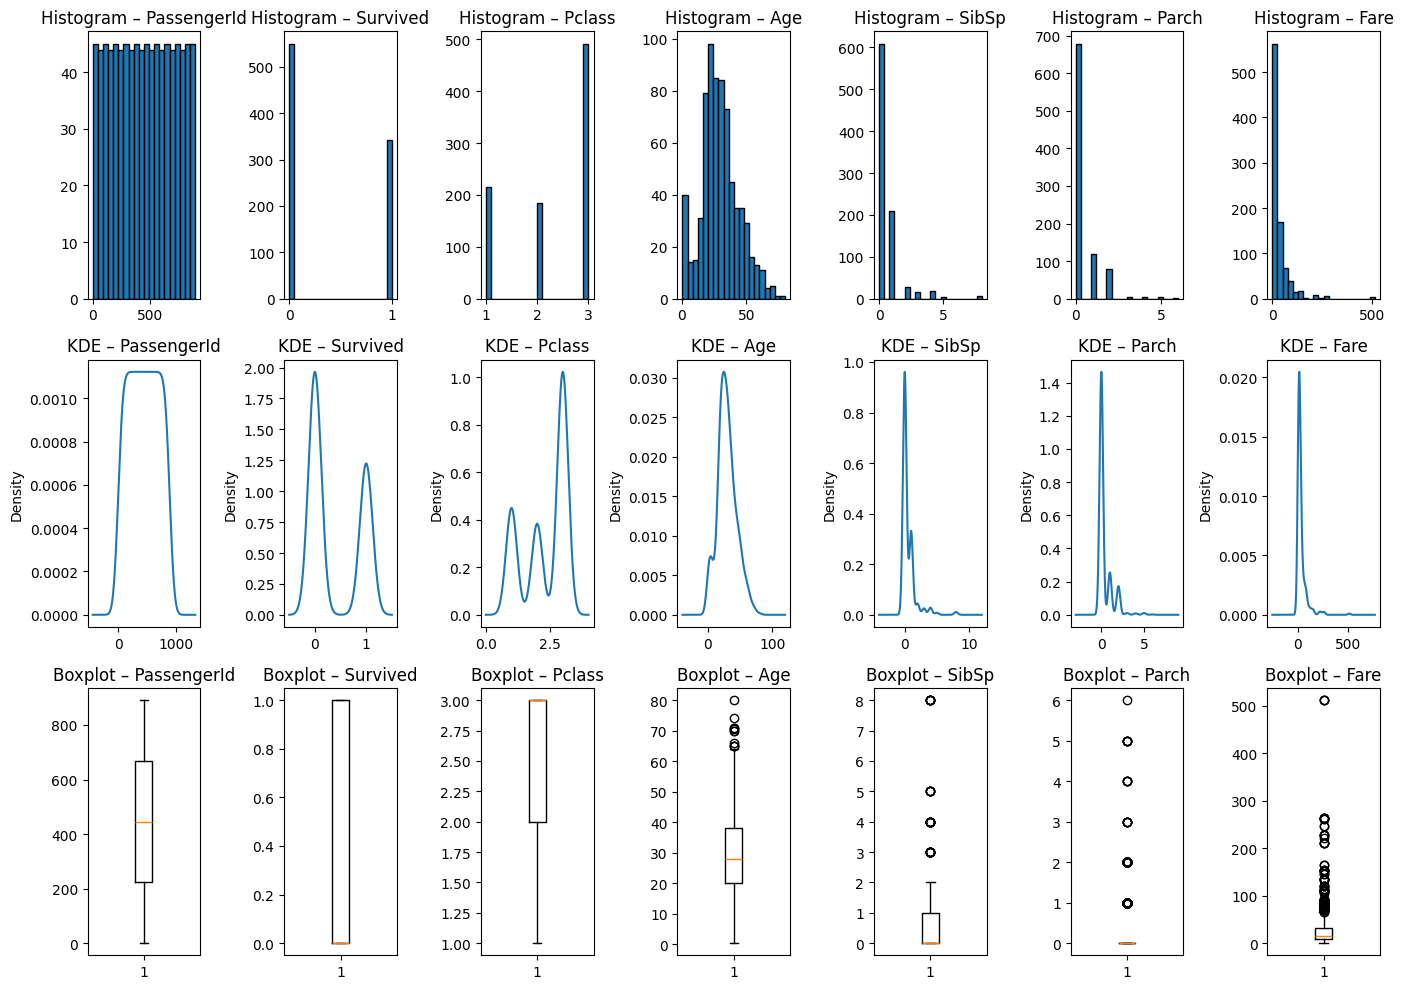

In [31]:
# DISTRIBUSI DATA
fig, axes = plt.subplots(3, len(num_cols), figsize=(14, 10))
for i, col in enumerate(num_cols):
    data = df[col].dropna()
    # Histogram
    axes[0, i].hist(data, bins=20, edgecolor='black')
    axes[0, i].set_title(f'Histogram – {col}')
    # KDE
    data.plot.kde(ax=axes[1, i])
    axes[1, i].set_title(f'KDE – {col}')
    # Boxplot
    axes[2, i].boxplot(data)
    axes[2, i].set_title(f'Boxplot – {col}')
plt.tight_layout()
plt.show()

In [32]:
# MISSING VALUES
missing = pd.DataFrame({
    'Count': df.isnull().sum(),
    '%'    : (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing[missing['Count'] > 0])

          Count      %
Age         177  19.87
Cabin       687  77.10
Embarked      2   0.22


In [33]:
# DUPLICATE
print("Jumlah duplikat:", df.duplicated().sum())

Jumlah duplikat: 0


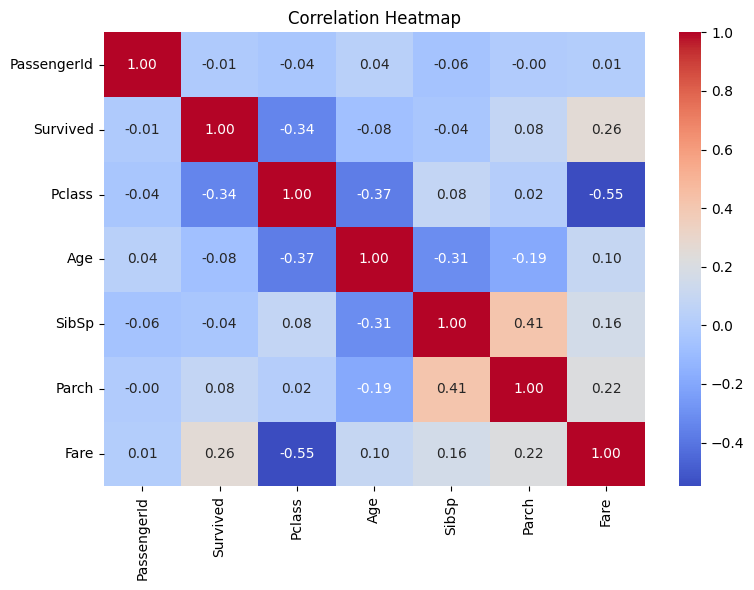

In [34]:
# KORELASI
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

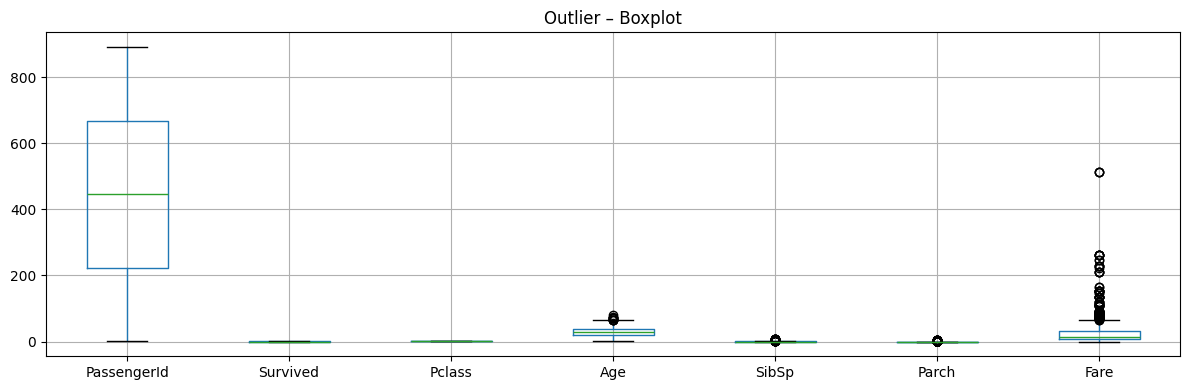


Jumlah outlier per kolom (IQR method):
  PassengerId: 0 outlier
  Survived: 0 outlier
  Pclass: 0 outlier
  Age: 11 outlier
  SibSp: 46 outlier
  Parch: 213 outlier
  Fare: 116 outlier


In [36]:
# DETEKSI OUTLIER (Visual + IQR)
# Visual (Boxplot semua numerik)
plt.figure(figsize=(12, 4))
df[num_cols].boxplot()
plt.title('Outlier – Boxplot')
plt.tight_layout()
plt.show()
# IQR
print("\nJumlah outlier per kolom (IQR method):")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"  {col}: {len(outliers)} outlier")

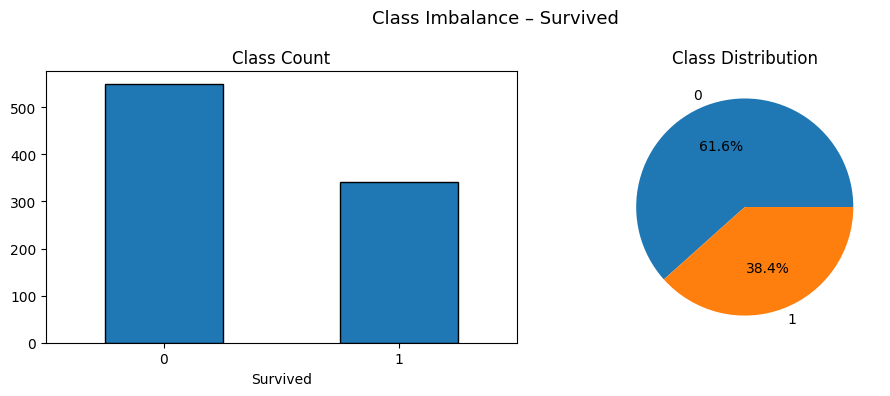

Survived
0    61.62
1    38.38


In [37]:
# CLASS IMBALANCE (target = 'Survived')
target = 'Survived'   # ganti sesuai kolom target kalian uy

counts = df[target].value_counts()
pct    = df[target].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
counts.plot.bar(ax=axes[0], edgecolor='black')
axes[0].set_title('Class Count')
axes[0].tick_params(axis='x', rotation=0)

axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%')
axes[1].set_title('Class Distribution')

plt.suptitle(f'Class Imbalance – {target}', fontsize=13)
plt.tight_layout()
plt.show()

print(pct.round(2).to_string())

## Data Cleaning

In [38]:
# MENGHAPUS DUPLICATE
df = df.drop_duplicates()
print("Shape setelah hapus duplikat:", df.shape)

Shape setelah hapus duplikat: (891, 12)


In [39]:
# MENANGANI MISSING VALUE
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [40]:
# Drop kolom jika missing > 50%
threshold = 0.5
df = df.loc[:, df.isnull().mean() < threshold]

# Drop baris jika missing di kolom penting
df = df.dropna(subset=['Survived'])          # ganti sesuai kolom target kalian uy

# Imputasi numerik → median
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# Imputasi kategori → modus
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing setelah imputasi:\n", df.isnull().sum())

Missing setelah imputasi:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_27905/3640504322.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [41]:
# MENGHAPUS OUTLIER (IQR Method)
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Hapus kolom target kalian dari deteksi outlier
target = 'Survived'
cols_for_outlier = [c for c in num_cols if c != target]

before = len(df)
for col in cols_for_outlier:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df  = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

print(f"Baris dihapus karena outlier: {before - len(df)}")
print("Shape setelah hapus outlier:", df.shape)

Baris dihapus karena outlier: 330
Shape setelah hapus outlier: (561, 11)


In [42]:
# MEMPERBAIKI FORMAT DATA (contoh: kolom tanggal)
# df['tanggal'] = pd.to_datetime(df['tanggal'], format='%Y-%m-%d')
# df['tahun']   = df['tanggal'].dt.year
# df['bulan']   = df['tanggal'].dt.month

# Dataset Titanic ini tidak punya kolom tanggal, uncomment jika datamu ada

In [43]:
# MENYAMAKAN KATEGORI
# Lowercase semua string dulu
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip().str.lower()

# Mapping manual (contoh kolom 'Sex')
df['Sex'] = df['Sex'].replace({'m': 'male', 'f': 'female'})

print(df['Sex'].value_counts())

Sex
male      422
female    139
Name: count, dtype: int64


/tmp/ipykernel_27905/2878325504.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [44]:
# MENGHAPUS KOLOM TIDAK RELEVAN
irrelevant_cols = ['PassengerId', 'Name']
irrelevant_cols = [c for c in irrelevant_cols if c in df.columns]
df = df.drop(columns=irrelevant_cols)
print("Kolom setelah hapus irrelevant:", df.columns.tolist())

Kolom setelah hapus irrelevant: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


In [46]:
# MEMPERBAIKI TYPO PADA KATEGORI
# Cek nilai unik kategori
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

Sex: <StringArray>
['male', 'female']
Length: 2, dtype: str
Ticket: <StringArray>
[       'a/5 21171', 'ston/o2. 3101282',           '113803',
           '373450',           '330877',            '17463',
           '237736',        'a/5. 2151',           '350406',
           '244373',
 ...
           '349212',           '349217',           '349257',
             '7552', 'c.a./soton 34068',  'soton/oq 392076',
           '211536',           '112053',           '111369',
           '370376']
Length: 520, dtype: str
Embarked: <StringArray>
['s', 'q', 'c']
Length: 3, dtype: str


/tmp/ipykernel_27905/2215193238.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [48]:
# Mapping typo → nilai yang benar (contoh)
# df['Embarked'] = df['Embarked'].replace({'s': 'S', 'c': 'C', 'q': 'Q'})

print("\nShape akhir:", df.shape)
df.head()


Shape akhir: (561, 9)


,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,male,22.0,1,0,a/5 21171,7.2500,s
2,1,3,female,26.0,0,0,ston/o2. 3101282,7.9250,s
3,1,1,female,35.0,1,0,113803,53.1000,s
4,0,3,male,35.0,0,0,373450,8.0500,s
5,0,3,male,28.0,0,0,330877,8.4583,q


## Data Preprocessing

In [51]:
# ENCODING KATEGORI

# Label Encoding → biner (2 nilai)
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])          # male/female → 0/1

# One-Hot Encoding → > 2 nilai
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
# → Embarked_Q, Embarked_S (Embarked_C jadi baseline)

print(df.head())

   Survived  Pclass  Sex   Age  SibSp  Parch            Ticket     Fare  \
0         0       3    1  22.0      1      0         a/5 21171   7.2500   
2         1       3    0  26.0      0      0  ston/o2. 3101282   7.9250   
3         1       1    0  35.0      1      0            113803  53.1000   
4         0       3    1  35.0      0      0            373450   8.0500   
5         0       3    1  28.0      0      0            330877   8.4583   

   Embarked_q  Embarked_s  
0       False        True  
2       False        True  
3       False        True  
4       False        True  
5        True       False  


In [53]:
# FEATURE SCALING
# Ambil hanya kolom numerik untuk scaling
features = [c for c in df.columns if c != target]
X_num = df[features].select_dtypes(include=np.number)   # ← tambahkan ini
y = df[target]

# Standardization
scaler_std = StandardScaler()
X_standardized = pd.DataFrame(scaler_std.fit_transform(X_num), columns=X_num.columns)

# Normalization
scaler_mm = MinMaxScaler()
X_normalized = pd.DataFrame(scaler_mm.fit_transform(X_num), columns=X_num.columns)

print("Standardized:\n", X_standardized.describe().loc[['mean','std']].round(2))
print("\nNormalized:\n",  X_normalized.describe().loc[['min','max']].round(2))

Standardized:
       Pclass  Sex  Age  SibSp  Parch  Fare
mean    -0.0  0.0 -0.0    0.0    0.0   0.0
std      1.0  1.0  1.0    1.0    0.0   1.0

Normalized:
      Pclass  Sex  Age  SibSp  Parch  Fare
min     0.0  0.0  0.0    0.0    0.0   0.0
max     1.0  1.0  1.0    1.0    0.0   1.0


In [54]:
# FEATURE ENGINEERING
df_fe = df.copy()

# Contoh: bikin fitur baru dari kolom yang ada
df_fe['FamilySize'] = df_fe['SibSp'] + df_fe['Parch'] + 1
df_fe['IsAlone']    = (df_fe['FamilySize'] == 1).astype(int)
df_fe['FarePerPerson'] = df_fe['Fare'] / df_fe['FamilySize']

print(df_fe[['SibSp', 'Parch', 'FamilySize', 'IsAlone', 'FarePerPerson']].head())

   SibSp  Parch  FamilySize  IsAlone  FarePerPerson
0      1      0           2        0         3.6250
2      0      0           1        1         7.9250
3      1      0           2        0        26.5500
4      0      0           1        1         8.0500
5      0      0           1        1         8.4583


In [56]:
# FEATURE SELECTION (SelectKBest)
X_sel = df_fe.drop(columns=[target]).select_dtypes(include=np.number)  # ← tambah ini
y_sel = df_fe[target]

selector = SelectKBest(score_func=f_classif, k=5)
selector.fit(X_sel, y_sel)

scores = pd.DataFrame({
    'Feature': X_sel.columns,
    'Score'  : selector.scores_
}).sort_values('Score', ascending=False)

print(scores)
best_features = scores.head(5)['Feature'].tolist()
print("5 Fitur terbaik:", best_features)

         Feature       Score
1            Sex  229.526041
0         Pclass   31.189958
5           Fare   28.158459
8  FarePerPerson   17.446321
7        IsAlone    5.518021
6     FamilySize    3.899063
3          SibSp    3.899063
2            Age    0.001056
4          Parch         NaN
5 Fitur terbaik: ['Sex', 'Pclass', 'Fare', 'FarePerPerson', 'IsAlone']


/home/tamamfb/Documents/ITS/how-AI-works/venv/lib64/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [4] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/tamamfb/Documents/ITS/how-AI-works/venv/lib64/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


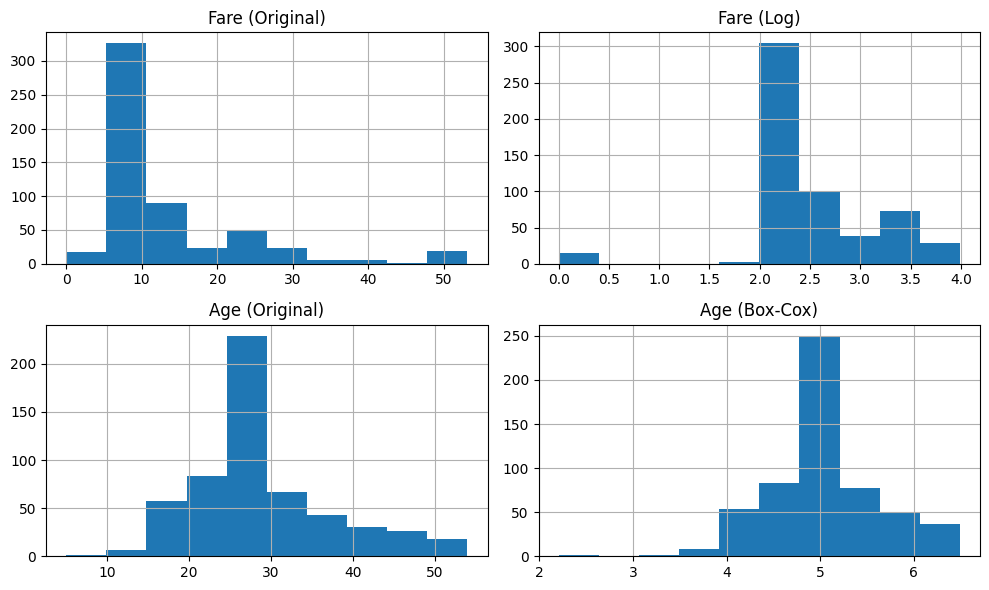

In [58]:
# TRANSFORMASI (Log Transform & Box-Cox)
# Cocok untuk kolom yang skewed

# Log Transform
df['Fare_log'] = np.log1p(df['Fare'])       # log1p aman untuk nilai 0

# Box-Cox (nilai harus > 0)
df['Age_boxcox'], _ = stats.boxcox(df['Age'] + 1)

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
df['Fare'].hist(ax=axes[0,0]);         axes[0,0].set_title('Fare (Original)')
df['Fare_log'].hist(ax=axes[0,1]);     axes[0,1].set_title('Fare (Log)')
df['Age'].hist(ax=axes[1,0]);          axes[1,0].set_title('Age (Original)')
df['Age_boxcox'].hist(ax=axes[1,1]);   axes[1,1].set_title('Age (Box-Cox)')
plt.tight_layout()
plt.show()

## Train/Test Split

In [62]:
target = 'Survived'
X = df.drop(columns=[target]).select_dtypes(include=np.number)
y = df[target]
print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (561, 8)
Shape y: (561,)


In [63]:
# PISAH X DAN Y + SPLIT 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (448, 8)
X_test : (113, 8)


In [64]:
# STRATIFIED SPLIT (distribusi kelas tetap proporsional)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,          # ← ini yg bikin stratified
    random_state=42
)

print("Distribusi y_train:\n", y_train.value_counts())
print("\nDistribusi y_test:\n",  y_test.value_counts())

Distribusi y_train:
 Survived
0    319
1    129
Name: count, dtype: int64

Distribusi y_test:
 Survived
0    81
1    32
Name: count, dtype: int64


In [65]:
# Handling data imbalance = SMOTE → hanya ke training set (ini sebenarnya maasuk ke data preprocess)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Sebelum SMOTE:", y_train.value_counts().to_dict())
print("Setelah SMOTE:", pd.Series(y_train_res).value_counts().to_dict())

Sebelum SMOTE: {0: 319, 1: 129}
Setelah SMOTE: {0: 319, 1: 319}


In [66]:
# CROSS VALIDATION (tanpa SMOTE dulu, untuk evaluasi awal)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print(f"CV Scores : {cv_scores.round(3)}")
print(f"Mean      : {cv_scores.mean():.4f}")
print(f"Std       : {cv_scores.std():.4f}")

CV Scores : [0.805 0.804 0.812 0.821 0.839]
Mean      : 0.8164
Std       : 0.0131


In [67]:
# STRATIFIED K-FOLD (lebih detail)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_f_train, X_f_val = X.iloc[train_idx], X.iloc[val_idx]
    y_f_train, y_f_val = y.iloc[train_idx], y.iloc[val_idx]
    print(f"Fold {fold} → Train: {len(X_f_train)}, Val: {len(X_f_val)}, "
          f"Pos rate train: {y_f_train.mean():.2f}, val: {y_f_val.mean():.2f}")

Fold 1 → Train: 448, Val: 113, Pos rate train: 0.29, val: 0.29
Fold 2 → Train: 449, Val: 112, Pos rate train: 0.29, val: 0.29
Fold 3 → Train: 449, Val: 112, Pos rate train: 0.29, val: 0.29
Fold 4 → Train: 449, Val: 112, Pos rate train: 0.29, val: 0.29
Fold 5 → Train: 449, Val: 112, Pos rate train: 0.29, val: 0.29
